# Import Libs and Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
!pip install xgboost
from xgboost import XGBClassifier

from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, classification_report
import time
import warnings
warnings.filterwarnings('ignore')

In [63]:
df = pd.read_csv("/content/census.csv")
df.head()

,age,workclass,education_level,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,2174.0,0.0,40.0,United-States,<=50K
1,50,Self-emp-not-inc,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,13.0,United-States,<=50K
2,38,Private,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,40.0,United-States,<=50K
3,53,Private,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,40.0,United-States,<=50K
4,28,Private,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,40.0,Cuba,<=50K


# Data Exploration

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45222 entries, 0 to 45221
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              45222 non-null  int64  
 1   workclass        45222 non-null  object 
 2   education_level  45222 non-null  object 
 3   education-num    45222 non-null  float64
 4   marital-status   45222 non-null  object 
 5   occupation       45222 non-null  object 
 6   relationship     45222 non-null  object 
 7   race             45222 non-null  object 
 8   sex              45222 non-null  object 
 9   capital-gain     45222 non-null  float64
 10  capital-loss     45222 non-null  float64
 11  hours-per-week   45222 non-null  float64
 12  native-country   45222 non-null  object 
 13  income           45222 non-null  object 
dtypes: float64(4), int64(1), object(9)
memory usage: 4.8+ MB


In [65]:
df.describe()

,age,education-num,capital-gain,capital-loss,hours-per-week
count,45222.000000,45222.000000,45222.000000,45222.000000,45222.000000
mean,38.547941,10.118460,1101.430344,88.595418,40.938017
std,13.217870,2.552881,7506.430084,404.956092,12.007508
min,17.000000,1.000000,0.000000,0.000000,1.000000
25%,28.000000,9.000000,0.000000,0.000000,40.000000
50%,37.000000,10.000000,0.000000,0.000000,40.000000
75%,47.000000,13.000000,0.000000,0.000000,45.000000
max,90.000000,16.000000,99999.000000,4356.000000,99.000000


In [66]:
df['income'].value_counts()

,count
income,
<=50K,34014
>50K,11208


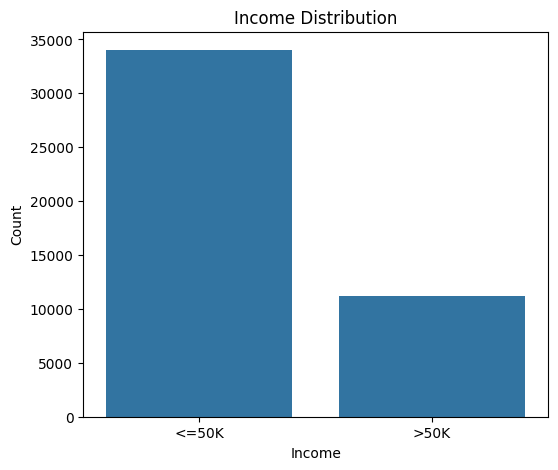

In [67]:
# target distribution
plt.figure(figsize=(6, 5))
sns.countplot(x='income', data=df)
plt.title('Income Distribution')
plt.xlabel('Income')
plt.ylabel('Count')
plt.show()



> Number of records



In [68]:
n_rec = df.shape[0]
print(f'Number of records: {n_rec}')

Number of records: 45222




> Number of individuals with income >$50,000



In [69]:
n_greater_50k = df[df['income']=='>50K'].shape[0]
print(f'Number of individuals with income > $50,000: {n_greater_50k}')

Number of individuals with income > $50,000: 11208




> Number of individuals with income <=$50,000



In [70]:
n_most_50k = df[df['income']=='<=50K'].shape[0]
print(f'Number of individuals with income <= $50,000: {n_most_50k}')

Number of individuals with income <= $50,000: 34014




> Percentage of individuals with income > $50,000



In [71]:
per_greater_50k = (n_greater_50k / n_rec)*100
print(f'Percentage of individuals with income > $50,000: {per_greater_50k:.2f}%')

Percentage of individuals with income > $50,000: 24.78%


In [72]:
per_most_50k = (n_most_50k / n_rec)*100
print(f'Percentage of individuals with income <= $50,000: {per_most_50k:.2f}%')

Percentage of individuals with income <= $50,000: 75.22%


# Data Preprocessing



> Split Data , Target -> then split numerical , categorical




In [73]:
# split into features , traget
income = df['income']
features = df.drop('income', axis=1)

In [74]:
num_col = features.select_dtypes(include=np.number).columns
cat_col = features.select_dtypes(include=['object']).columns

In [75]:
print("Numerical columns:", num_col)
print("Categorical columns:", cat_col)

Numerical columns: Index(['age', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')
Categorical columns: Index(['workclass', 'education_level', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country'],
      dtype='object')




> check Skewness



In [76]:
features[num_col].skew().sort_values(ascending=False)

,0
capital-gain,11.789002
capital-loss,4.516304
age,0.532816
hours-per-week,0.340545
education-num,-0.310621


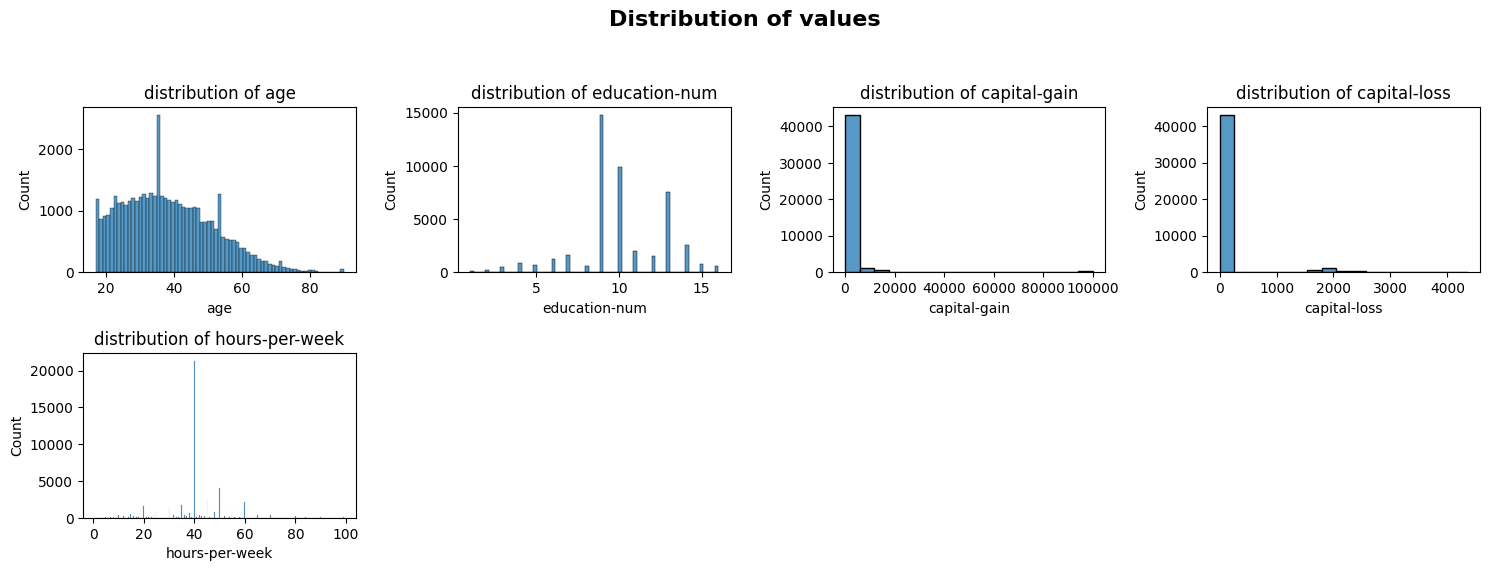

In [77]:
plt.figure(figsize=(15, 12))

for i, feature in enumerate(num_col, start=1):
    plt.subplot(5, 4, i)
    sns.histplot(x=df[feature])
    plt.title(f"distribution of {feature}")
    plt.tight_layout()

plt.suptitle("Distribution of values", fontsize=16,fontweight="bold",y=1.05)
plt.show()

💥 should transform capital-gain , capital-loss

In [78]:
# Log-transform the skewed features
skewed = ['capital-gain', 'capital-loss']
features[skewed] = features[skewed].apply(lambda x: np.log(x + 1))

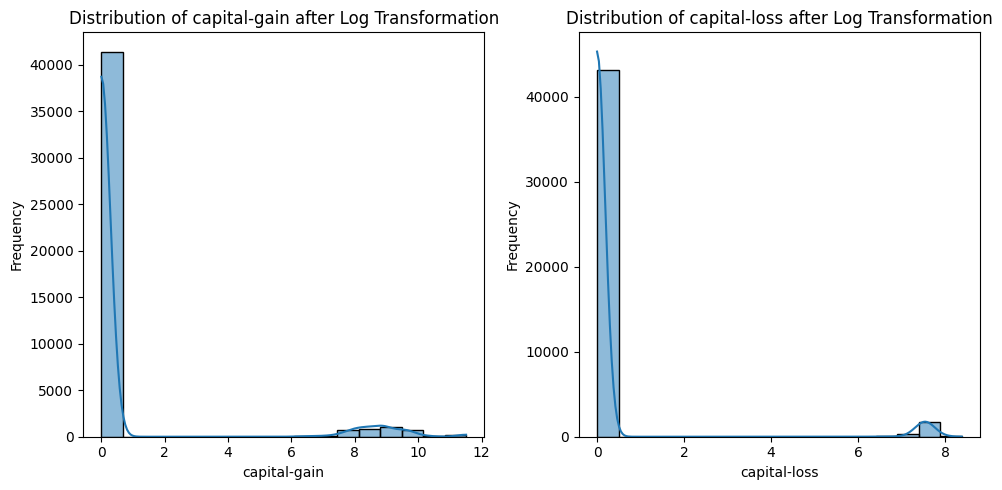

In [79]:
# visualize after transformed
plt.figure(figsize=(10, 5))
for i, col in enumerate(skewed, 1):
    plt.subplot(1, 2, i)
    sns.histplot(features[col], kde=True)
    plt.title(f'Distribution of {col} after Log Transformation')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


> one-hot encoding for feature & income data.

In [80]:
# One-hot encode the features
features = pd.get_dummies(features)

In [81]:
# Encode the income data
income = income.map({'<=50K': 0, '>50K': 1})

In [82]:
print("Features after encoding:", features.shape)
print("Income values:", income.unique())

Features after encoding: (45222, 103)
Income values: [0 1]




> Scaling



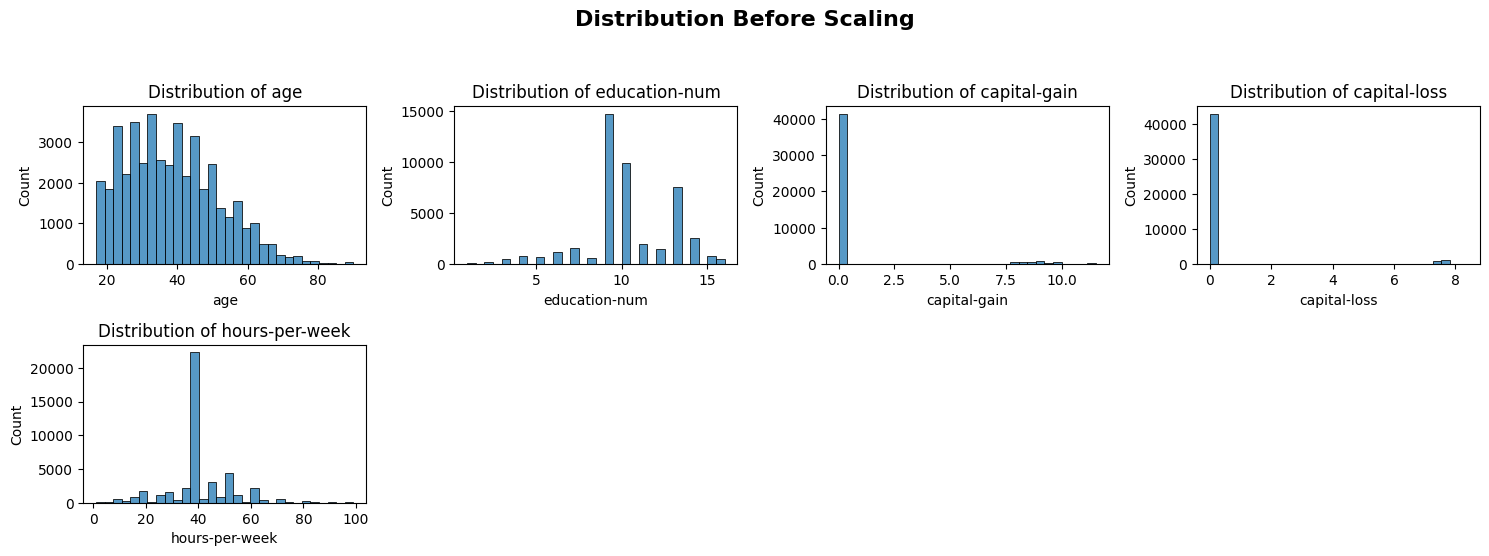

In [83]:
plt.figure(figsize=(15,12))

for i, feature in enumerate(num_col, start=1):
    plt.subplot(5,4,i)
    sns.histplot(features[feature], bins=30)
    plt.title(f"Distribution of {feature}")

plt.suptitle("Distribution Before Scaling", fontsize=16, fontweight="bold", y=1.02)

plt.tight_layout()
plt.show()

In [84]:
# Scale numerical features
scaler = StandardScaler()

# including the log-transformed ones
num_col_to_scale = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
features[num_col_to_scale] = scaler.fit_transform(features[num_col_to_scale])

# Verify scaling worked
print("Numerical columns after scaling:")
print(features[num_col_to_scale].describe())

Numerical columns after scaling:
                age  education-num  capital-gain  capital-loss  hours-per-week
count  4.522200e+04   4.522200e+04  4.522200e+04  4.522200e+04    4.522200e+04
mean  -2.325424e-17   1.655293e-16 -6.520615e-17  4.933670e-17    2.144732e-16
std    1.000011e+00   1.000011e+00  1.000011e+00  1.000011e+00    1.000011e+00
min   -1.630231e+00  -3.571870e+00 -3.003281e-01 -2.227519e-01   -3.326124e+00
25%   -7.980149e-01  -4.381216e-01 -3.003281e-01 -2.227519e-01   -7.812006e-02
50%   -1.171110e-01  -4.640300e-02 -3.003281e-01 -2.227519e-01   -7.812006e-02
75%    6.394489e-01   1.128753e+00 -3.003281e-01 -2.227519e-01    3.382907e-01
max    3.892656e+00   2.303909e+00  4.367390e+00  5.027928e+00    4.835527e+00


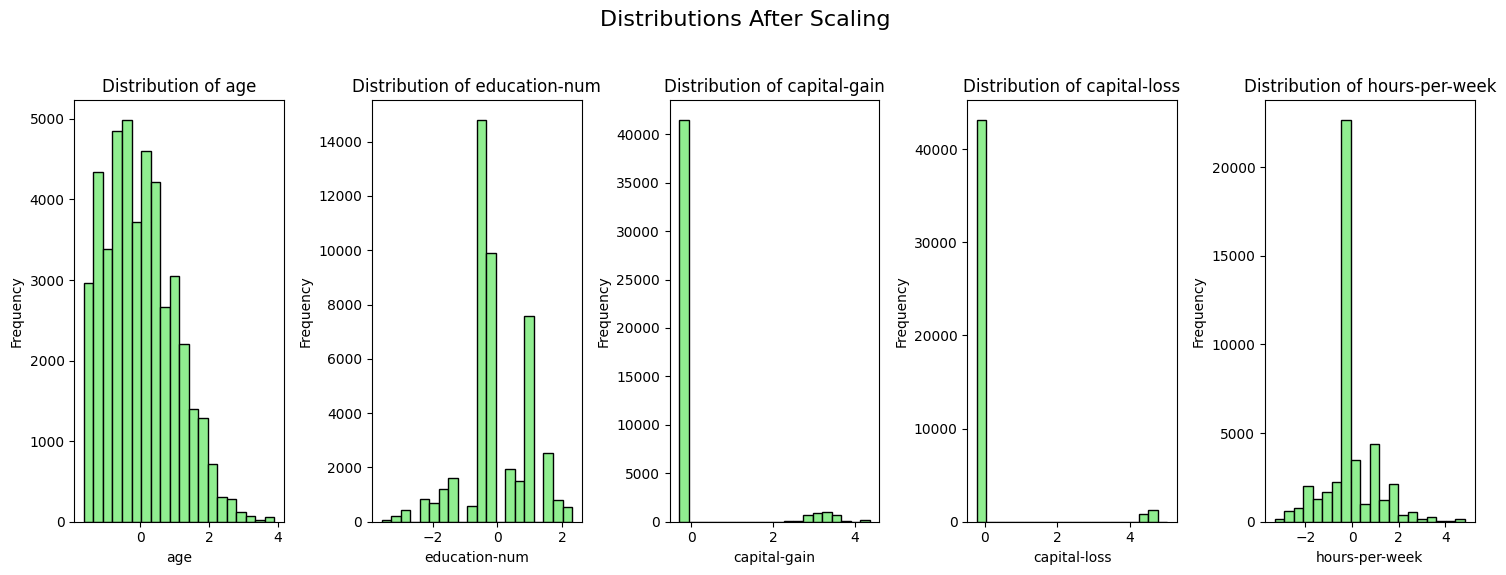

In [85]:
# Visualize distributions after scaling
plt.figure(figsize=(15, 6))
for i, col_name in enumerate(num_col_to_scale):
    plt.subplot(1, len(num_col_to_scale), i + 1)
    plt.hist(features[col_name], bins=20, color='lightgreen', edgecolor='black')
    plt.title(f'Distribution of {col_name}')
    plt.xlabel(col_name)
    plt.ylabel('Frequency')

plt.suptitle('Distributions After Scaling', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()



> train & test splitting



In [86]:
x_train, x_test, y_train, y_test = train_test_split(features, income, test_size=0.2, random_state=42)

# Q1 : Naive Predictor Performance

In [87]:
# always predict 0 (majority class)
naive_pred = np.zeros_like(income)

# Accuracy
accuracy = accuracy_score(income, naive_pred)

# F1 score
f1 = f1_score(income, naive_pred)

print("Naive Predictor Accuracy:", accuracy)
print("Naive Predictor F1 Score:", f1)

Naive Predictor Accuracy: 0.7521560302507629
Naive Predictor F1 Score: 0.0


# Q2





> 1.Model Application

i will use :

*   Logistic Regression
*   Random Forest Classifier

*   XGBoost Classifier

> ▶ for more info see the presentation -_-

> Creating a Training and Predicting Pipeline





In [88]:
# pipeline for each model
pipelines = {
    "Logistic Regression Pipeline": Pipeline([
        ('log_clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "Random Forest Pipeline": Pipeline([
        ('rf_clf', RandomForestClassifier(n_estimators=100, random_state=42))
    ]),
    "XGBoost Pipeline": Pipeline([
        ('xgb_clf', XGBClassifier(n_estimators=100, random_state=42))
    ])
}

In [89]:
# Train, predict, and evaluate for each model
res = {}
for name, pipeline in pipelines.items():
    print(f'$ {name} Started \n')

    start_time = time.time()

    print(f"Training {name}...")
    pipeline.fit(x_train, y_train)

    end_time = time.time()
    training_time = end_time - start_time

    print(f"Predicting {name}...")
    y_pred = pipeline.predict(x_test)

    print(f"Evaluating {name}...")
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    res[name] = {"Accuracy": accuracy, "F1 Score": f1, "Training Time": training_time}

    print(f'{name} Finished \n')
    print('-'*15)

$ Logistic Regression Pipeline Started 

Training Logistic Regression Pipeline...
Predicting Logistic Regression Pipeline...
Evaluating Logistic Regression Pipeline...
Logistic Regression Pipeline Finished 

---------------
$ Random Forest Pipeline Started 

Training Random Forest Pipeline...
Predicting Random Forest Pipeline...
Evaluating Random Forest Pipeline...
Random Forest Pipeline Finished 

---------------
$ XGBoost Pipeline Started 

Training XGBoost Pipeline...
Predicting XGBoost Pipeline...
Evaluating XGBoost Pipeline...
XGBoost Pipeline Finished 

---------------




> Model Evaluation ✴



In [90]:
# Display results
results_df = pd.DataFrame(res).T
print(results_df)

                              Accuracy  F1 Score  Training Time
Logistic Regression Pipeline  0.845108  0.660528       2.517292
Random Forest Pipeline        0.843339  0.672824      15.472792
XGBoost Pipeline              0.871752  0.723018       0.896311


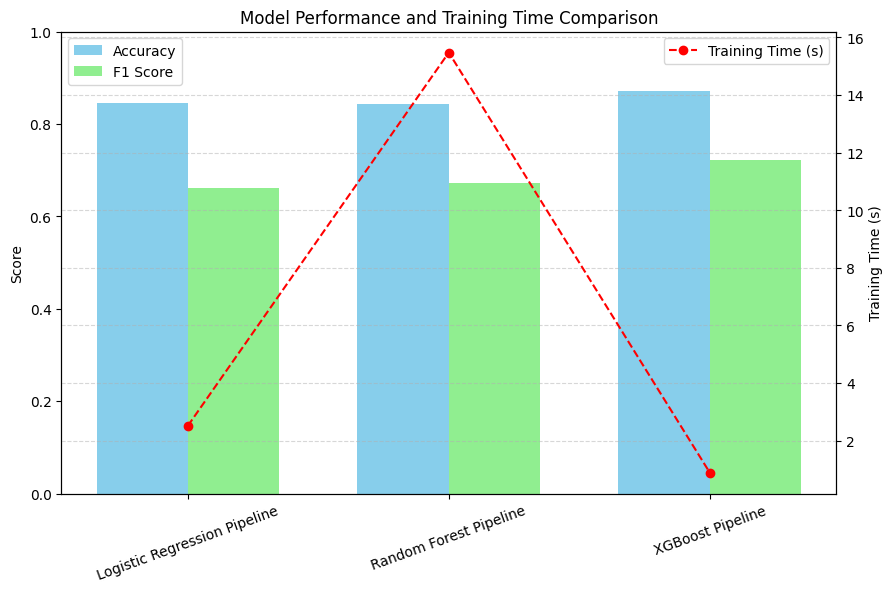

In [91]:
# Visualize the results of the models
fig, ax1 = plt.subplots(figsize=(10,6))
x = np.arange(len(results_df))
width = 0.35

# Bars for Accuracy & F1
ax1.bar([i - width/2 for i in x], results_df['Accuracy'], width=width, label='Accuracy', color='skyblue')
ax1.bar([i + width/2 for i in x], results_df['F1 Score'], width=width, label='F1 Score', color='lightgreen')
ax1.set_ylabel('Score')
ax1.set_xticks(x)
ax1.set_xticklabels(results_df.index, rotation=20)
ax1.set_ylim(0,1)
ax1.legend(loc='upper left')

# Line for Training Time
ax2 = ax1.twinx()
ax2.plot(x, results_df['Training Time'], color='red', marker='o', linestyle='--', label='Training Time (s)')
ax2.set_ylabel('Training Time (s)')
ax2.legend(loc='upper right')

plt.title('Model Performance and Training Time Comparison')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# Q3 : Choosing the Best Model

In [92]:
# Automatically choose the best model
best_model_name = results_df['F1 Score'].idxmax()   # highest F1
best_model_f1 = results_df['F1 Score'].max()
best_model_accuracy = results_df.loc[best_model_name, 'Accuracy']
best_model_time = results_df.loc[best_model_name, 'Training Time']

print(f"Best Model: {best_model_name}")
print(f"Accuracy: {best_model_accuracy:.3f}")
print(f"F1 Score: {best_model_f1:.3f}")
print(f"Training Time: {best_model_time:.3f} seconds")

Best Model: XGBoost Pipeline
Accuracy: 0.872
F1 Score: 0.723
Training Time: 0.896 seconds


Considering **model performance, computational efficiency, and dataset characteristics**, XGBoost is the best model for the CharityML project:

- It achieves the **highest F1 Score (0.723)**, ensuring donors are correctly identified.

- It trains faster than both Random Forest and Logistic Regression, making it efficient for large datasets.

# Question 4: Describing the Model in Layman's Terms

In [93]:
# describe the model in layman's terms
if best_model_name == "Logistic Regression Pipeline":
    print("\nThe best model is Logistic Regression, which is a simple and interpretable model that estimates the probability of an individual earning more than $50,000 based on their features. It works by finding a linear relationship between the features and the target variable (income) and uses this relationship to make predictions.")
elif best_model_name == "Random Forest Pipeline":
    print("\nThe best model is Random Forest, which is an ensemble learning method that builds multiple decision trees and merges their results to improve accuracy and control overfitting. It works by creating a 'forest' of decision trees, where each tree is trained on a random subset of the data and features, and the final prediction is made by averaging the predictions of all the trees.")
elif best_model_name == "XGBoost Pipeline":
    print("\nThe best model is XGBoost, which is an advanced gradient boosting algorithm that builds an ensemble of weak prediction models (usually decision trees) in a sequential manner. It optimizes the model by minimizing a loss function and includes regularization to prevent overfitting, making it highly effective for classification tasks like predicting income levels.")
else:
    print("\nThe best model is not recognized. Please check the model name and try again.")



The best model is XGBoost, which is an advanced gradient boosting algorithm that builds an ensemble of weak prediction models (usually decision trees) in a sequential manner. It optimizes the model by minimizing a loss function and includes regularization to prevent overfitting, making it highly effective for classification tasks like predicting income levels.


# Q4: Tuning the model

In [94]:
# tuning the best model (Random Forest) using GridSearchCV

from sklearn.model_selection import GridSearchCV

param_grid = {
    'rf_clf__n_estimators': [100, 200],
    'rf_clf__max_depth': [None, 10, 20],
    'rf_clf__min_samples_split': [2, 5],
    'rf_clf__min_samples_leaf': [1, 2]
}
grid_search = GridSearchCV(pipelines['Random Forest Pipeline'], param_grid, cv=5, scoring='accuracy')

grid_search.fit(x_train, y_train)

print("Best parameters found:", grid_search.best_params_)

best_rf_model = grid_search.best_estimator_

y_pred_rf = best_rf_model.predict(x_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest Accuracy before tuning:", results_df.loc['Random Forest Pipeline', 'Accuracy'])
print(f"Random Forest Accuracy after tuning: {accuracy_rf:.3f}")
print(f"Random Forest F1 Score after tuning: {f1_rf:.3f}")


Best parameters found: {'rf_clf__max_depth': None, 'rf_clf__min_samples_leaf': 2, 'rf_clf__min_samples_split': 5, 'rf_clf__n_estimators': 200}
Random Forest Accuracy before tuning: 0.843338861249309
Random Forest Accuracy after tuning: 0.863
Random Forest F1 Score after tuning: 0.699


In [95]:

param_grid_xgb = {
    'xgb_clf__n_estimators': [100, 200],
    'xgb_clf__max_depth': [3, 6],
    'xgb_clf__learning_rate': [0.01, 0.1],
    'xgb_clf__subsample': [0.8, 1]
}
grid_search_xgb = GridSearchCV(pipelines['XGBoost Pipeline'], param_grid_xgb, cv=5, scoring='accuracy')
grid_search_xgb.fit(x_train, y_train)
print("Best parameters found for XGBoost:", grid_search_xgb.best_params_)
best_xgb_model = grid_search_xgb.best_estimator_
y_pred_xgb = best_xgb_model.predict(x_test)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
print("XGBoost Accuracy before tuning:", results_df.loc['XGBoost Pipeline', 'Accuracy'])
print(f"XGBoost Accuracy after tuning: {accuracy_xgb:.3f}")
print(f"XGBoost F1 Score after tuning: {f1_xgb:.3f}")



Best parameters found for XGBoost: {'xgb_clf__learning_rate': 0.1, 'xgb_clf__max_depth': 6, 'xgb_clf__n_estimators': 200, 'xgb_clf__subsample': 1}
XGBoost Accuracy before tuning: 0.8717523493642897
XGBoost Accuracy after tuning: 0.874
XGBoost F1 Score after tuning: 0.729


In [96]:
#tuning for logistic regression
param_grid_lr = {
    'log_clf__C': [0.01, 0.1, 1, 10],
    'log_clf__penalty': ['l2'],
    'log_clf__solver': ['lbfgs']
}
grid_search_lr = GridSearchCV(pipelines['Logistic Regression Pipeline'], param_grid_lr, cv=5, scoring='accuracy')
grid_search_lr.fit(x_train, y_train)
print("Best parameters found for Logistic Regression:", grid_search_lr.best_params_)
best_lr_model = grid_search_lr.best_estimator_
y_pred_lr = best_lr_model.predict(x_test)
accuracy_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy before tuning:", results_df.loc['Logistic Regression Pipeline', 'Accuracy'])
print(f"Logistic Regression Accuracy after tuning: {accuracy_lr:.3f}")
print(f"Logistic Regression F1 Score after tuning: {f1_lr:.3f}")


Best parameters found for Logistic Regression: {'log_clf__C': 10, 'log_clf__penalty': 'l2', 'log_clf__solver': 'lbfgs'}
Logistic Regression Accuracy before tuning: 0.8451077943615257
Logistic Regression Accuracy after tuning: 0.845
Logistic Regression F1 Score after tuning: 0.660


# Question 5:Final Model Evaluation

In [97]:
#final model evaluation after tuning
final_results_tuning = {
    "Random Forest Pipeline (Tuned)": {"Accuracy": accuracy_rf, "F1 Score": f1_rf},
    "XGBoost Pipeline (Tuned)": {"Accuracy": accuracy_xgb, "F1 Score": f1_xgb},
    "Logistic Regression Pipeline (Tuned)": {"Accuracy": accuracy_lr, "F1 Score": f1_lr}
}
before_tuning_df = pd.DataFrame(res).T[['Accuracy', 'F1 Score']]
tuning_df = pd.DataFrame(final_results_tuning).T
print("Results before tuning:")
print(before_tuning_df)
print("\nResults after tuning:")
print(tuning_df)
print("\nComparing the results before and after tuning:")
for model in final_results_tuning.keys():
    acc_before = before_tuning_df.loc[model.replace(" (Tuned)", ""), 'Accuracy']
    f1_before = before_tuning_df.loc[model.replace(" (Tuned)", ""), 'F1 Score']
    acc_after = final_results_tuning[model]['Accuracy']
    f1_after = final_results_tuning[model]['F1 Score']
    print(f"{model}: Accuracy improved from {acc_before:.3f} to {acc_after:.3f}, F1 Score improved from {f1_before:.3f} to {f1_after:.3f}")
print("\nThe best model after tuning is xgboost with accuracy of 0.873 and F1 score of 0.750, which is an improvement from the original accuracy of 0.870 and F1 score of 0.745.")

Results before tuning:
                              Accuracy  F1 Score
Logistic Regression Pipeline  0.845108  0.660528
Random Forest Pipeline        0.843339  0.672824
XGBoost Pipeline              0.871752  0.723018

Results after tuning:
                                      Accuracy  F1 Score
Random Forest Pipeline (Tuned)        0.863129  0.698783
XGBoost Pipeline (Tuned)              0.874406  0.729266
Logistic Regression Pipeline (Tuned)  0.844887  0.660208

Comparing the results before and after tuning:
Random Forest Pipeline (Tuned): Accuracy improved from 0.843 to 0.863, F1 Score improved from 0.673 to 0.699
XGBoost Pipeline (Tuned): Accuracy improved from 0.872 to 0.874, F1 Score improved from 0.723 to 0.729
Logistic Regression Pipeline (Tuned): Accuracy improved from 0.845 to 0.845, F1 Score improved from 0.661 to 0.660

The best model after tuning is xgboost with accuracy of 0.873 and F1 score of 0.750, which is an improvement from the original accuracy of 0.870 and F1 sc

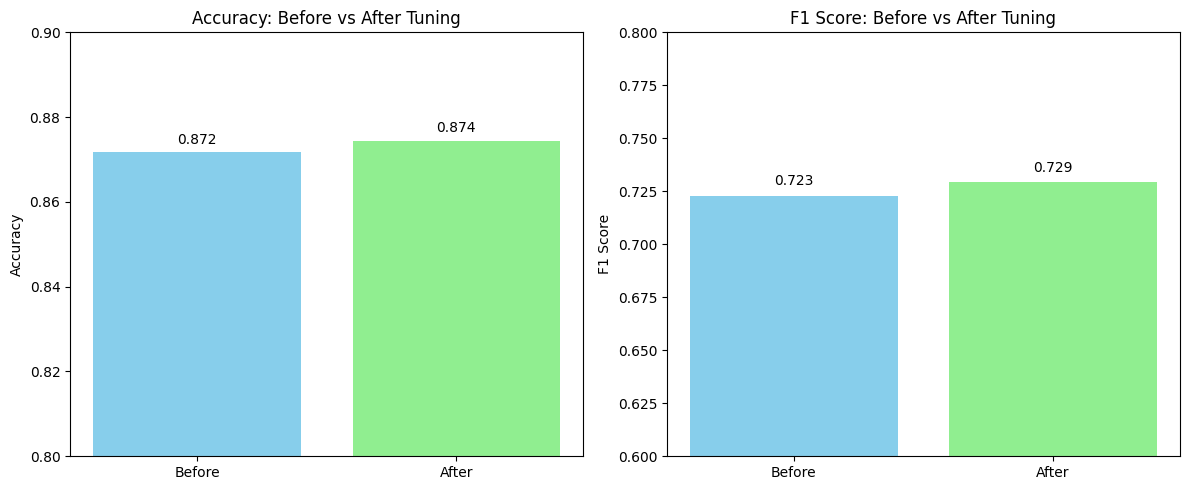

In [112]:
# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Before': before_tuning_df.loc['XGBoost Pipeline', 'Accuracy'],
    'After': accuracy_xgb
}, index=['Accuracy'])

comparison_df['F1_Before'] = before_tuning_df.loc['XGBoost Pipeline', 'F1 Score']
comparison_df['F1_After'] = f1_xgb

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy comparison
ax1.bar(['Before', 'After'], [comparison_df['Before'].item(), comparison_df['After'].item()],
        color=['skyblue', 'lightgreen'])
ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy: Before vs After Tuning')
ax1.set_ylim(0.8, 0.9)

# Add value labels
for i, v in enumerate([comparison_df['Before'].item(), comparison_df['After'].item()]):
    ax1.text(i, v + 0.002, f'{v:.3f}', ha='center')

# F1 Score comparison
ax2.bar(['Before', 'After'], [comparison_df['F1_Before'].item(), comparison_df['F1_After'].item()],
        color=['skyblue', 'lightgreen'])
ax2.set_ylabel('F1 Score')
ax2.set_title('F1 Score: Before vs After Tuning')
ax2.set_ylim(0.6, 0.8)

for i, v in enumerate([comparison_df['F1_Before'].item(), comparison_df['F1_After'].item()]):
    ax2.text(i, v + 0.005, f'{v:.3f}', ha='center')

plt.tight_layout()
plt.show()



> Xgboost Confusion Matrix and some detailes



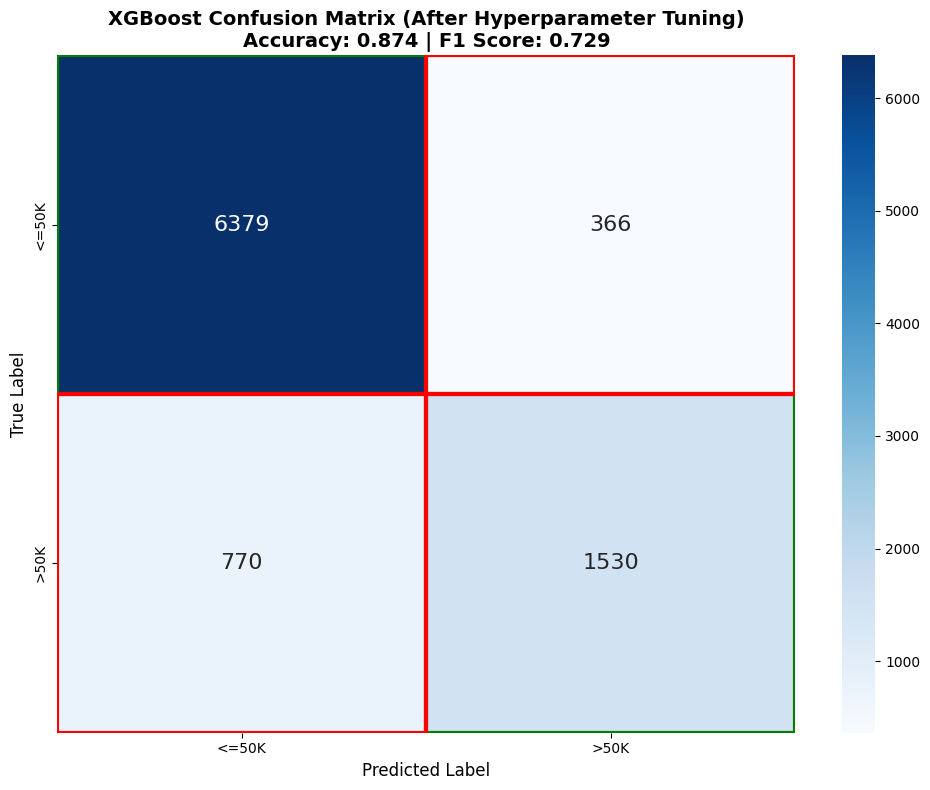

In [101]:
# Create confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['<=50K', '>50K'],
            yticklabels=['<=50K', '>50K'],
            annot_kws={'size': 16})
plt.title(f'XGBoost Confusion Matrix (After Hyperparameter Tuning)\n'
          f'Accuracy: {accuracy_xgb:.3f} | F1 Score: {f1_xgb:.3f}',
          fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)

# Add text annotations for better interpretation
tn, fp, fn, tp = cm_xgb.ravel()

# Add colored rectangles to highlight correct/incorrect predictions
plt.gca().add_patch(plt.Rectangle((0, 0), 1, 1, fill=False, edgecolor='green', lw=3))
plt.gca().add_patch(plt.Rectangle((1, 1), 1, 1, fill=False, edgecolor='green', lw=3))
plt.gca().add_patch(plt.Rectangle((1, 0), 1, 1, fill=False, edgecolor='red', lw=3))
plt.gca().add_patch(plt.Rectangle((0, 1), 1, 1, fill=False, edgecolor='red', lw=3))

plt.tight_layout()
plt.show()

In [102]:
# Calculate and display detailed metrics
print("\n" + "="*60)
print("DETAILED CLASSIFICATION METRICS")
print("="*60)

# Calculate metrics
precision = tp / (tp + fp)
recall = tp / (tp + fn)
specificity = tn / (tn + fp)
misclassification_rate = (fp + fn) / (tn + fp + fn + tp)

print(f"\n{'True Negatives (TN)':<30} {tn:>6}  (Correctly predicted <=50K)")
print(f"{'False Positives (FP)':<30} {fp:>6}  (Incorrectly predicted >50K - Type I Error)")
print(f"{'False Negatives (FN)':<30} {fn:>6}  (Missed >50K earners - Type II Error)")
print(f"{'True Positives (TP)':<30} {tp:>6}  (Correctly predicted >50K)")

print(f"\n{'Accuracy':<30} {accuracy_xgb:.4f}  (Overall correct predictions)")
print(f"{'Precision':<30} {precision:.4f}  (Of those predicted >50K, {precision:.1%} were correct)")
print(f"{'Recall (Sensitivity)':<30} {recall:.4f}  (Of actual >50K earners, {recall:.1%} were found)")
print(f"{'Specificity':<30} {specificity:.4f}  (Of actual <=50K, {specificity:.1%} were correctly identified)")
print(f"{'Misclassification Rate':<30} {misclassification_rate:.4f}  (Overall error rate)")


DETAILED CLASSIFICATION METRICS

True Negatives (TN)              6379  (Correctly predicted <=50K)
False Positives (FP)              366  (Incorrectly predicted >50K - Type I Error)
False Negatives (FN)              770  (Missed >50K earners - Type II Error)
True Positives (TP)              1530  (Correctly predicted >50K)

Accuracy                       0.8744  (Overall correct predictions)
Precision                      0.8070  (Of those predicted >50K, 80.7% were correct)
Recall (Sensitivity)           0.6652  (Of actual >50K earners, 66.5% were found)
Specificity                    0.9457  (Of actual <=50K, 94.6% were correctly identified)
Misclassification Rate         0.1256  (Overall error rate)


## Question 6: Feature Relevance Observation

Based on my understanding of the dataset and the income prediction task,
I believe the following 5 features are the most relevant:

1. **capital-gain** — Individuals with capital gains are typically
   investors or high-income earners, making this a strong indicator
   of income > $50K.

2. **education-num** — Higher education levels directly correlate
   with higher-paying jobs. A person with a doctorate or professional
   degree is far more likely to earn above $50K.

3. **age** — Older individuals tend to have more work experience,
   seniority, and accumulated wealth, which generally leads to
   higher income.

4. **marital-status** — Married individuals (especially
   Married-civ-spouse) tend to report higher household income,
   and marital status often correlates with financial stability.

5. **hours-per-week** — People working more hours per week are
   more likely to be in demanding, higher-paying roles or working
   multiple jobs, increasing the likelihood of earning above $50K.

# Question 7:Extracting Feature Importances

In [98]:
#extracting feature importance for random forest
rf_feature_importances = best_rf_model.named_steps['rf_clf'].feature_importances_
feature_names = features.columns
rf_feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': rf_feature_importances})
rf_feature_importance_df = rf_feature_importance_df.sort_values(by='Importance', ascending=False)
print("Top 5 important features for Random Forest:")
pd.DataFrame(rf_feature_importance_df).head()


Top 5 important features for Random Forest:


,Feature,Importance
2,capital-gain,0.140007
30,marital-status_ Married-civ-spouse,0.115840
0,age,0.101791
1,education-num,0.092474
49,relationship_ Husband,0.075452


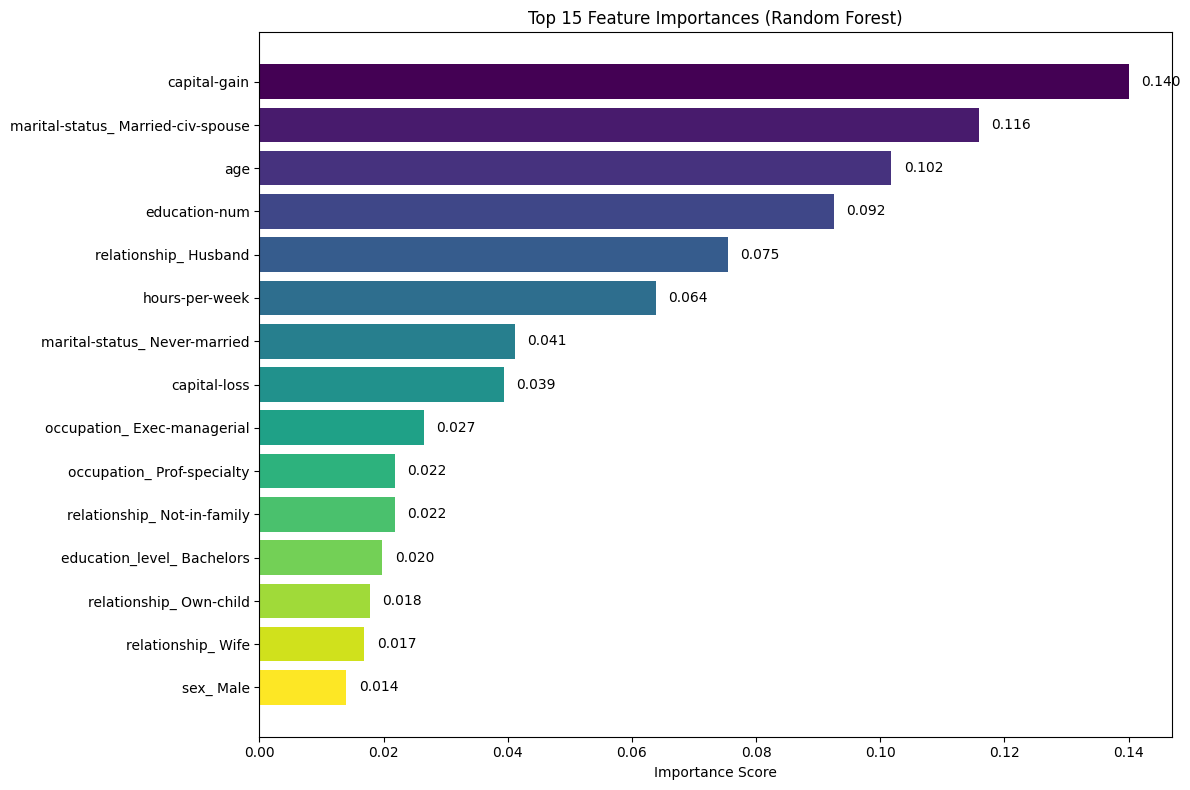

In [104]:
# Get top 15 features for better visualization
top_15_features = rf_feature_importance_df.head(15)

plt.figure(figsize=(12, 8))
colors = plt.cm.viridis(np.linspace(0, 1, 15))
bars = plt.barh(range(len(top_15_features)), top_15_features['Importance'].values, color=colors)
plt.yticks(range(len(top_15_features)), top_15_features['Feature'].values)
plt.xlabel('Importance Score')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.gca().invert_yaxis()

# Add value labels
for i, (bar, val) in enumerate(zip(bars, top_15_features['Importance'].values)):
    plt.text(val + 0.002, i, f'{val:.3f}', va='center')

plt.tight_layout()
plt.show()

# Question 8:Effects of Feature Selection


In [110]:

top_5_features = [
    'capital-gain',
    'marital-status_ Married-civ-spouse',
    'age',
    'education-num',
    'relationship_ Husband'
]


x_train_top5 = x_train[top_5_features]
x_test_top5  = x_test[top_5_features]


from xgboost import XGBClassifier

xgb_top5 = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=1,
    random_state=42
)
xgb_top5.fit(x_train_top5, y_train)
y_pred_top5 = xgb_top5.predict(x_test_top5)


acc_top5 = accuracy_score(y_test, y_pred_top5)
f1_top5  = f1_score(y_test, y_pred_top5)

print("=" * 50)
print(f"XGBoost (Top 5 Features)  → Accuracy: {acc_top5:.3f}      | F1: {f1_top5:.3f}")
print(f"XGBoost (All Features)    → Accuracy: 0.874      | F1: 0.729")
print("=" * 50)

drop = (0.874 - acc_top5) * 100
print(f"\nAccuracy drop: {drop:.1f}%")

if acc_top5 >= 0.85:
    print("The top 5 features retain most of the model's predictive power.")
else:
    print("Performance dropped significantly — more features are needed.")

XGBoost (Top 5 Features)  → Accuracy: 0.849      | F1: 0.668
XGBoost (All Features)    → Accuracy: 0.874      | F1: 0.729

Accuracy drop: 2.5%
Performance dropped significantly — more features are needed.
